# Proyek Analisis Sentimen terhadap Ulasan Pengguna Aplikasi BRImo
- **Nama:** Chatarina Evangelista Sitorus
- **Email:** chatarinaevas304@gmail.com
- **ID Dicoding:** dicodingchatzz

Proyek ini bertujuan untuk memahami persepsi pengguna terhadap aplikasi BRImo melalui analisis sentimen berdasarkan ulasan di Google Play Store.

## **1. Import Packages/Libraries yang Digunakan**

In [7]:
# Install sebelum import
!pip install nltk
!pip install Sastrawi
!pip install wordcloud
!pip install tensorflow

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/375.7 MB 1.5 MB/s eta 0:04:06
   ---------------------------------------- 1.0/375.7 MB 1.6 MB/s eta 0:03:59
   ---------------------------------------- 1.3/375.7 MB 1.3 MB/s eta 0:04:39
   ---------------------------------------- 1.8/375.7 MB 1.6 MB/s eta 0:03:54
   ---------------------------------------- 2.1/375.7 MB 1.6 MB/s eta 0:03:50
   ---------------------------------------- 2.6/375.7 MB 1.8 MB/s eta 0:03:26
   ---------------------------------------- 3.1/375.7 MB 1.8 MB/s eta 0:03:24
   ---------------------------------------- 3.7/375.7 MB 1.9 MB/s eta 0:03:18
   ---------------------------------------- 4.2/375.

In [3]:
# Import library umum 
import pandas as pd  
import numpy as np  
import datetime as dt  # Untuk manipulasi waktu dan tanggal
import re  # Ekspresi reguler (regex)
import string  # Operasi pada karakter, termasuk tanda baca
pd.options.mode.chained_assignment = None  # Menonaktifkan warning chained assignment
seed = 0
np.random.seed(seed)  # Set seed agar hasil reproducible

# Visualisasi 
import matplotlib.pyplot as plt  
import seaborn as sns

# Visualisasi berbasis teks 
from wordcloud import WordCloud  # Membuat word cloud dari teks

# Preprocessing teks dasar 
from nltk.stem import WordNetLemmatizer  # Lematisasi kata (khusus Bahasa Inggris)
from nltk.tokenize import word_tokenize  # Memecah kalimat menjadi kata
from nltk.corpus import stopwords  # Daftar kata umum yang sering dibuang
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')

# Preprocessing & evaluasi model ML 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

# Stemming dan stopword Bahasa Indonesia 
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Untuk stemming Bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Stopword remover Indo

# Deep learning dengan TensorFlow/Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Flatten, Bidirectional, SimpleRNN, Dropout, Embedding, MaxPooling1D, Conv1D, GlobalMaxPooling1D, SpatialDropout1D, LSTM
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


import requests
import csv
from io import StringIO


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chata\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chata\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **2. Memuat Dataset**

In [4]:
# Load dataset dari file CSV
df = pd.read_csv("Dataset/dataset_review_brimo.csv")

# Menampilkan seluruh data
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,24868505-ec59-4b9f-9814-652642d8cc5b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Hasil Update hanya mengutamakan tampilan saja ...,1,7,2.1.0,2021-01-14 05:05:02,"Hai, Sobat BRI. Mohon maaf atas kendala yang d...",2025-01-12 18:10:06,2.1.0
1,31b68644-a796-47ab-87be-b245e036d6a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Aplikasi ribet, screenshot pun dibatasi beda d...",1,1,2.80.0,2025-04-07 13:06:50,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2025-04-07 13:38:37,2.80.0
2,173d222b-3d3b-4a81-aec3-59c74da2023b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi sy stelah update malah crash force cl...,2,113,2.80.0,2025-03-20 04:27:49,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-03-20 19:00:04,2.80.0
3,8b622a19-4ad2-4657-bfff-b6f872d14fb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya makin jelek aja !!! Kenapa harus m...,1,82,2.80.0,2025-03-22 06:59:32,"Hai Sobat BRI, mohon maaf atas kendala BRImo y...",2025-03-22 14:48:54,2.80.0
4,1310ede7-796f-40f8-8965-a5cfd49ab556,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,setelah update terakhir selalu muncul notifika...,2,17,2.81.0,2025-04-02 08:32:21,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-04-02 09:31:59,2.81.0
...,...,...,...,...,...,...,...,...,...,...,...
32995,a2f1864d-cd91-4eee-91b4-5beb2a4b212b,yuni mahfudz,https://play-lh.googleusercontent.com/a/ACg8oc...,"Kmren baru dwonload ,langsung tak coba transak...",5,0,2.1.0,2021-02-07 11:38:58,Hi Kak. Terima kasih atas ulasannya. Semoga ap...,2021-02-07 14:02:08,2.1.0
32996,2b7d8ee8-7f0a-444b-9359-8aac13f6218f,Andisa Putra,https://play-lh.googleusercontent.com/a-/ALV-U...,"Mobile bri sering terblokir , jadi dalam satu ...",1,0,NaN,2020-11-05 17:35:18,Selamat sore Bapak Andisa Putra. Mohon maaf at...,2020-11-05 18:02:02,NaN
32997,4aef33f4-ce52-4849-adec-4d668d06178f,jefrey gunawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi mobile banking yg paling parah dianta...,1,0,2.3.1,2021-05-04 18:47:53,"Sobat BRI, kami sarankan untuk melakukan Updat...",2021-06-18 09:58:02,2.3.1
32998,19b74db9-13e4-4542-ab00-38e457f06aa1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Knapa ya setiap mau download gak bisa"" ..tolon...",3,0,NaN,2020-01-29 11:32:21,"Selamat siang Bapak/Ibu, mohon maaf atas ketid...",2020-01-29 12:08:05,NaN


## **3. Exploratory Data Analysis (EDA) dan Preprocessing Data**


 **- Memahami struktur data**

In [5]:
df.sample(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
11609,89dd92e9-051d-4c3c-a463-db274656d549,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bagus, keamanan harus di utamakan.",5,0,2.78.0,2025-02-21 10:28:21,"Hai Sobat BRI, terima kasih atas ulasannya. Se...",2025-02-21 15:49:54,2.78.0
7564,807f5401-97b5-4c9d-b0a4-ce3fdf1b1aa5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi menyulitkan... Kualitas video sudah m...,1,3,2.25.0,2022-08-16 01:58:03,"Sobat BRI, mohon maaf atas kendala yang dialam...",2022-08-16 06:19:55,2.25.0
18998,09628d6c-db4c-4e47-9b38-c0eb3677e497,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Setelah saya update ke versi baru.. Masya Alla...,2,0,2.1.0,2021-01-19 02:54:52,Selamat pagi Ibu Inka. Mohon maaf atas ketidak...,2021-01-19 08:01:17,2.1.0
13504,bcadd7f8-964b-4dfa-80a5-84f5cc6f126c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Tolong dong ,ini aplikasi Brimo malah ga bisa ...",2,0,2.76.0,2025-01-07 14:27:26,"Hai, Sobat BRI. Mohon maaf atas kendala yang d...",2025-01-07 15:19:41,2.76.0
15058,92ceb78e-5515-4f26-9be0-4d7664e75b01,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kenapa ya saya mau daftar brimo ini sulit seka...,5,6,2.46.0,2023-10-04 18:50:52,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2023-10-07 13:03:20,2.46.0


In [6]:
# Meninjau jumlah baris dan kolom
jumlah_data = df.shape[0]
jumlah_fitur = df.shape[1]
print(f"\nDataset terdiri dari {jumlah_data} baris dan {jumlah_fitur} kolom.")



Dataset terdiri dari 33000 baris dan 11 kolom.


In [7]:
# Meninjau tipe data dan informasi umum
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33000 entries, 0 to 32999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              33000 non-null  object
 1   userName              33000 non-null  object
 2   userImage             33000 non-null  object
 3   content               33000 non-null  object
 4   score                 33000 non-null  int64 
 5   thumbsUpCount         33000 non-null  int64 
 6   reviewCreatedVersion  29222 non-null  object
 7   at                    33000 non-null  object
 8   replyContent          32854 non-null  object
 9   repliedAt             32854 non-null  object
 10  appVersion            29222 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.8+ MB


In [8]:
# Menampilkan statistik deskriptif untuk semua kolom
df.describe(include='all')


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
count,33000,33000,33000,33000,33000.000000,33000.000000,29222,33000,32854,32854,29222
unique,33000,1414,1414,32775,NaN,NaN,102,32982,11030,32780,102
top,03c0bde8-aa16-4e49-a966-e731b40a2076,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat membantu sekali,NaN,NaN,2.80.0,2025-03-18 14:47:13,"Sobat BRI, mohon maaf atas kendala yang dialam...",2022-10-08 12:52:09,2.80.0
freq,1,31587,31587,18,NaN,NaN,3653,2,168,2,3653
mean,NaN,NaN,NaN,NaN,2.685697,5.937182,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.745497,51.928290,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,5.000000,1.000000,NaN,NaN,NaN,NaN,NaN


In [9]:
# Menampilkan jumlah nilai unik tiap kolom
df.nunique()


reviewId                33000
userName                 1414
userImage                1414
content                 32775
score                       5
thumbsUpCount             343
reviewCreatedVersion      102
at                      32982
replyContent            11030
repliedAt               32780
appVersion                102
dtype: int64

**- Menangani data duplikat**

In [10]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


 **- Menangani data yang hilang**

In [11]:
df.isna().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    3778
at                         0
replyContent             146
repliedAt                146
appVersion              3778
dtype: int64

In [12]:
# Menghapus baris yang memiliki nilai NaN langsung pada df
df.dropna(inplace=True)

# Cek jumlah baris setelah penghapusan
print("Jumlah data setelah menghapus nilai NaN:", df.shape[0])

Jumlah data setelah menghapus nilai NaN: 29077


In [38]:
# Cek kembali apakah masih ada data yang hilang
print("\nCek missing value kembali:")
print(df.isna().sum())


Cek missing value kembali:
reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64


In [13]:
# Daftar kolom yang tidak relevan untuk analisis sentimen
irrelevant_columns = [
    'reviewId', 'userImage', 'thumbsUpCount',
    'reviewCreatedVersion', 'replyContent', 'repliedAt', 'appVersion'
]

# Salin DataFrame asli sebelum dilakukan penghapusan kolom
filtered_df = df.copy()

# Hapus kolom yang tidak diperlukan (hanya jika kolom tersebut ada)
filtered_df.drop(columns=[col for col in irrelevant_columns if col in filtered_df.columns], inplace=True)

# Bandingkan jumlah kolom sebelum dan sesudah penghapusan
kolom_awal = df.shape[1]
kolom_setelah = filtered_df.shape[1]
print(f"Jumlah kolom sebelum penghapusan: {kolom_awal}")
print(f"Jumlah kolom setelah penghapusan: {kolom_setelah}")

# Tampilkan nama kolom yang tersisa
print("Kolom yang tersisa:", filtered_df.columns.tolist())


Jumlah kolom sebelum penghapusan: 11
Jumlah kolom setelah penghapusan: 4
Kolom yang tersisa: ['userName', 'content', 'score', 'at']


**- Menampilkan ringkasan DataFrame setelah pembersihan kolom**

In [14]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29077 entries, 0 to 32999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  29077 non-null  object
 1   content   29077 non-null  object
 2   score     29077 non-null  int64 
 3   at        29077 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [15]:
filtered_df

,userName,content,score,at
0,Pengguna Google,Hasil Update hanya mengutamakan tampilan saja ...,1,2021-01-14 05:05:02
1,Pengguna Google,"Aplikasi ribet, screenshot pun dibatasi beda d...",1,2025-04-07 13:06:50
2,Pengguna Google,aplikasi sy stelah update malah crash force cl...,2,2025-03-20 04:27:49
3,Pengguna Google,Aplikasinya makin jelek aja !!! Kenapa harus m...,1,2025-03-22 06:59:32
4,Pengguna Google,setelah update terakhir selalu muncul notifika...,2,2025-04-02 08:32:21
...,...,...,...,...
32993,Toha Makhshun,Alhamdulillah sangat membantu saya dalam melak...,5,2021-01-10 19:01:35
32994,Ayhuu,Kenapa versi terupdate nya susah sekali pada s...,1,2023-01-10 21:17:14
32995,yuni mahfudz,"Kmren baru dwonload ,langsung tak coba transak...",5,2021-02-07 11:38:58
32997,jefrey gunawan,Aplikasi mobile banking yg paling parah dianta...,1,2021-05-04 18:47:53


- Dataset telah dibersihkan dari nilai kosong (NaN) di seluruh kolom.
- Kolom tidak relevan telah dihapus untuk menyisakan hanya userName, content, score, dan at.
- Data berjumlah 29.077 baris dan siap digunakan untuk analisis sentimen.

**- Analisis Distribusi Skor Ulasan**

score
1    12327
2     2839
3     2506
4     2122
5     9283
Name: count, dtype: int64


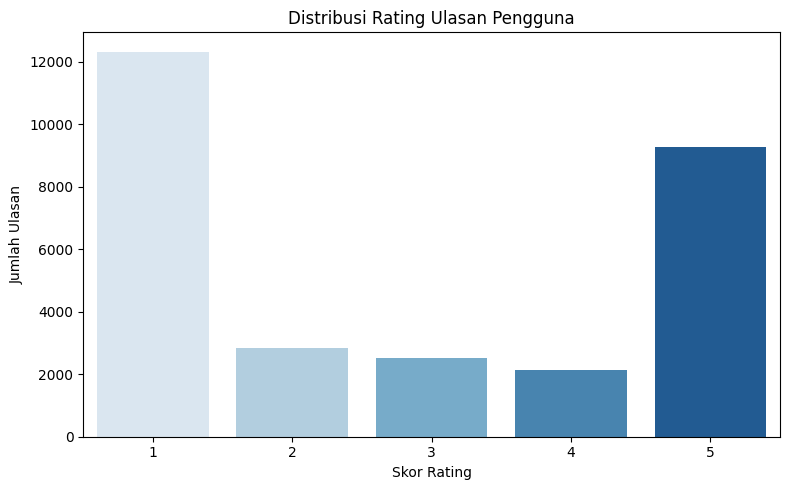

In [16]:
# Hitung jumlah ulasan untuk setiap skor (1 hingga 5)
score_distribution = filtered_df['score'].value_counts().sort_index()
print(score_distribution)

# Buat DataFrame baru untuk memudahkan penggunaan hue
score_df = score_distribution.reset_index()
score_df.columns = ['score', 'count']

# Visualisasi distribusi skor ulasan dengan palet baru dan tanpa warning
plt.figure(figsize=(8, 5))
sns.barplot(data=score_df, x='score', y='count', hue='score', palette=sns.color_palette("Blues", 5).as_hex(), legend=False)
plt.title('Distribusi Rating Ulasan Pengguna')
plt.xlabel('Skor Rating')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()


**Insight:**
- Skor 1 mendominasi, menunjukkan tingkat ketidakpuasan yang tinggi dari pengguna.
- Skor 5 juga cukup besar, menandakan masih ada pengguna yang puas.
- Skor 2–4 relatif sedikit, menunjukkan ulasan cenderung bersifat ekstrem (sangat puas atau sangat tidak puas), bukan netral.

**- Menghapus Duplikat Ulasan Berdasarkan Isi**

In [17]:
# Hitung jumlah baris sebelum dan sesudah
sebelum = filtered_df.shape[0]
filtered_df = filtered_df.drop_duplicates(subset='content')
sesudah = filtered_df.shape[0]

print(f"Jumlah ulasan duplikat yang dihapus: {sebelum - sesudah}")
print("Setelah hapus duplikat:")
filtered_df.info()


Jumlah ulasan duplikat yang dihapus: 215
Setelah hapus duplikat:
<class 'pandas.core.frame.DataFrame'>
Index: 28862 entries, 0 to 32999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  28862 non-null  object
 1   content   28862 non-null  object
 2   score     28862 non-null  int64 
 3   at        28862 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


**Analisis kembali distribusi skor ulasan**

score
1    12325
2     2839
3     2506
4     2114
5     9078
Name: count, dtype: int64


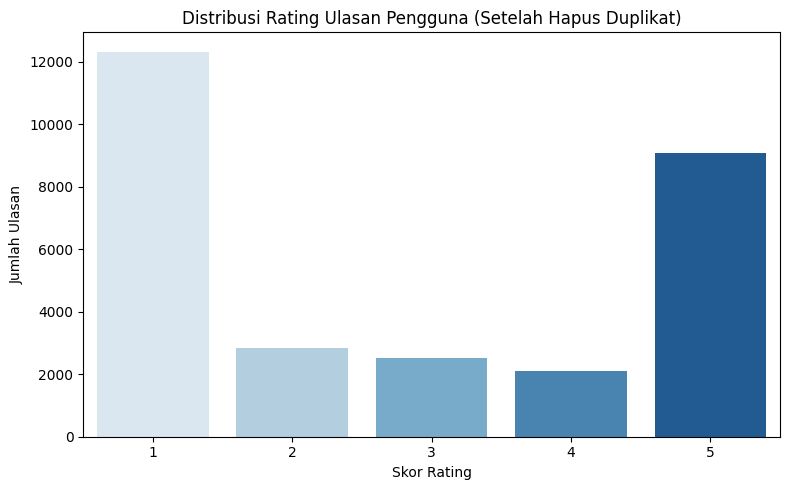

In [18]:
# Hitung ulang distribusi skor setelah penghapusan duplikat
score_distribution = filtered_df['score'].value_counts().sort_index()
print(score_distribution)

# Buat DataFrame baru untuk plotting
score_df = score_distribution.reset_index()
score_df.columns = ['score', 'count']

# Visualisasi distribusi skor ulasan
plt.figure(figsize=(8, 5))
sns.barplot(data=score_df, x='score', y='count', hue='score', palette=sns.color_palette("Blues", 5).as_hex(), legend=False)
plt.title('Distribusi Rating Ulasan Pengguna (Setelah Hapus Duplikat)')
plt.xlabel('Skor Rating')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()


**Insight:**
- Skor 1 tetap paling dominan, mengindikasikan banyak ulasan negatif unik, bukan spam atau pengulangan.
- Skor 5 masih cukup tinggi, menunjukkan adanya kepuasan dari sebagian pengguna.
- Distribusi tetap menunjukkan polaritas tinggi: ulasan cenderung sangat puas atau sangat kecewa, jarang yang netral.

**- Visualisasi Frekuensi Kata Sebelum Preprocessing Text**

In [19]:
from collections import Counter

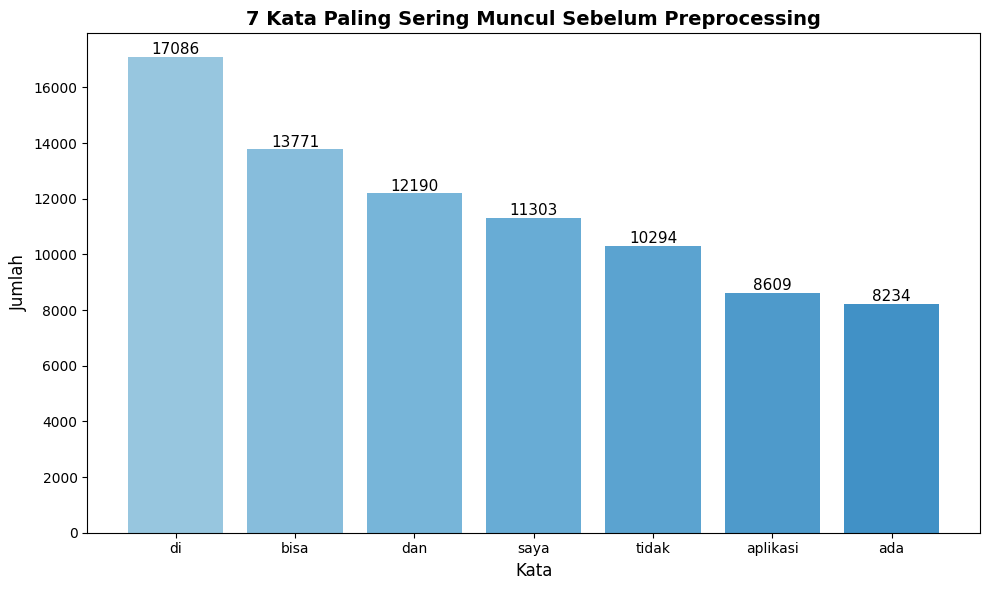

In [22]:
# Menggabungkan seluruh isi kolom 'content' jadi satu string besar
corpus_text = " ".join(filtered_df["content"].astype(str))

# Memisahkan kata berdasarkan spasi
tokens_list = corpus_text.split()

# Menghitung jumlah kemunculan tiap kata dan mengambil kata paling sering muncul
frekuensi_kata = Counter(tokens_list)
kata_teratas = frekuensi_kata.most_common(7)

# Pisahkan kata dan jumlahnya untuk visualisasi
kata, jumlah = zip(*kata_teratas)

# Visualisasi bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(
    kata,
    jumlah,
    color=plt.cm.Blues(range(100, 100 + 10 * len(kata), 10))
)
plt.title("7 Kata Paling Sering Muncul Sebelum Preprocessing", fontsize=14, fontweight='bold')
plt.xlabel("Kata", fontsize=12)
plt.ylabel("Jumlah", fontsize=12)
plt.xticks(rotation=0)

# Menambahkan label jumlah di atas bar
for bar, jumlahnya in zip(bars, jumlah):
    plt.text(bar.get_x() + bar.get_width() / 2, jumlahnya + 100, str(jumlahnya), ha='center', fontsize=11)

plt.tight_layout()
plt.show()


**Insight:** 
Dari visualisasi 7 kata teratas sebelum preprocessing:
- Kata seperti **"di", "bisa", "dan", "saya"** adalah kata umum yang kurang relevan untuk analisis sentimen.
- Kata **"aplikasi"**, **"tidak"** dan **"ada"** mulai mencerminkan konteks ulasan BRImo.
  
Diperlukan *stopword removal* agar analisis fokus pada kata bermakna dan tidak bias oleh kata-kata umum.

**- Visualisasi WordCloud Sebelum Preprocessing Text**

In [23]:
from wordcloud import ImageColorGenerator, STOPWORDS

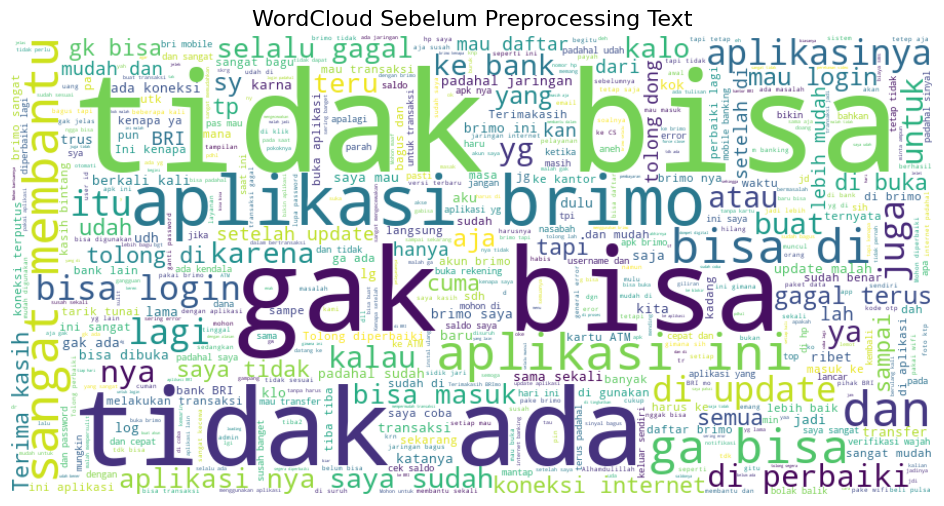

In [24]:
# Menggabungkan seluruh isi ulasan
teks_ulasan = ' '.join(filtered_df['content'].astype(str))

# Menambahkan stopwords custom
stop_kata = set(STOPWORDS)
stop_kata.update(['https', 'RT', 'co', 'amp', '...'])

# Membuat objek WordCloud
cloud = WordCloud(
    stopwords=stop_kata,
    background_color="white",
    max_words=500,
    height=450,
    width=900
).generate(teks_ulasan)

# Menampilkan WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(cloud, interpolation='hamming')
plt.axis('off')
plt.title("WordCloud Sebelum Preprocessing Text", fontsize=16)
plt.show()


**Insight:**
- Kata dominan seperti “tidak”, “bisa”, “gak”, “aplikasi”, “brimo” menunjukkan banyak ulasan terkait masalah akses atau penggunaan aplikasi.
- Munculnya kata “login”, “gagal”, “update” menegaskan adanya keluhan teknis.
- Banyak kata umum/informal (“nya”, “saya”, “aja”) maka perlu dilakukan preprocessing agar analisis lebih fokus dan bermakna.

## **4. Preprocessing Text**


 Tahap membersihkan dan mempersiapkan data teks mentah sebelum digunakan dalam sentiment analysis. Tujuannya agar teks menjadi lebih konsisten, bersih, dan bermakna secara semantik. Hal ini dilakukan untuk:
 - Mengurangi noise atau kekacauan data seperti simbol, emotikon, kata tidak penting, dan singkatan.
 - Membantu model memahami arti kata sebenarnya (misalnya "gak", "nggak", "tidak" dianggap satu arti).
 - Meningkatkan akurasi dan efisiensi proses feature extraction dan machine learning.

In [25]:
preprocessed_df = filtered_df.copy() #Menyalin dataframe untuk dilakukan preprocessing text

In [26]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28862 entries, 0 to 32999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  28862 non-null  object
 1   content   28862 non-null  object
 2   score     28862 non-null  int64 
 3   at        28862 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


Instalasi `tqdm` digunakan untuk menampilkan progress bar saat menerapkan fungsi pada banyak data, sehingga membantu memantau sejauh mana proses telah berjalan, terutama saat melakukan preprocessing seperti normalisasi, penghapusan stopword, atau stemming pada dataset berukuran besar.

In [27]:
!pip install tqdm

In [28]:
from tqdm import tqdm
tqdm.pandas() 

In [37]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chata\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()


**Membaca Kamus Slang**

In [204]:
import json
with open("dataset/combined_slang_words.txt", "r", encoding="utf-8") as f:
    slang_dict = json.load(f)

with open("dataset/combined_stop_words.txt", "r", encoding="utf-8") as f:
    stopword_list = [line.strip() for line in f if line.strip() != ""]

with open("dataset/combined_root_words.txt", "r", encoding="utf-8") as f:
    root_word_list = [line.strip() for line in f if line.strip() != ""]

slang_dict.update({
    "motong": "potong",
    "pulak": "pula",
    "sy": "saya",
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "ngga": "tidak",
    "nggak": "tidak",
    "udh": "sudah",
    "dpt": "dapat",
    "bgt": "banget",
    "dr": "dari",
    "tp": "tapi",
    "sm": "sama",
    "blm": "belum",
    "tdk": "tidak",
    "jd": "jadi",
    "dg": "dengan",
    "ny": "nya",
    "trs": "terus",
    "aj": "saja",
    "nomer": "nomor",
    "jngn": "jangan",
    "dikit": "sedikit",
    "dikit2": "sedikit",
    "tulis": "tulisan",
    "brapa": "berapa",
    "kasi": "kasih",
    "ngebug": "bug",      
    "gatau": "tidak tahu",
    "eror": "error",
    "gmn": "bagaimana",
    "gimana": "bagaimana",           
    "sebelom": "sebelum",
    "pdhl": "padahal",        
    "dtg": "datang",
    "tehnologi": "teknologi",
    "jg": "juga",
    "ribeut": "sulit",
    "ribet": "sulit",
    "apk": "aplikasi",
    "hp": "handphone",
    "tetep": "tetap",
    "sdh": "sudah",
    "trus": "terus",
    "truss": "terus",
    "pakek": "pakai",
    "sebenernya": "sebenarnya",
    "terimakasih": "terima kasih",
})

stopword_list.extend([
    "dong", "tolong", "nih", "aja", "loh", "deh", "sih", "ya", "yg", "nya",
    "yaa", "yaaah", "yah", "ah", "ih", "eh", "lah", "kan", "kok",
    "min", "bang", "kak", "gan", "om", "bro", "sis", "iya", "huffttt"
])
# Fungsi untuk mengganti slang dengan kata baku
def fixSlangWords(text):
    if pd.isnull(text):
        return ""
    return ' '.join([slang_dict.get(str(word), word) for word in str(text).split()])

**Fungsi-fungsi Preprocessing**

In [205]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # menghapus mention seperti @user
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # menghapus hashtag
    text = re.sub(r'\bRT\b', '', text)  # menghapus kata RT (retweet)
    text = re.sub(r"http\S+", '', text)  # menghapus link/url
    text = re.sub(r'[0-9]+', '', text)  # menghapus angka
    text = re.sub(r'[^\w\s]', '', text)  # menghapus simbol dan karakter non-alfabet
    text = text.replace('\n', ' ')  # mengganti newline dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = text.strip()  # hapus spasi di awal dan akhir
    return text

def casefoldingText(text):
    return text.lower()  # mengubah semua huruf menjadi lowercase untuk konsistensi


def tokenizingText(text): 
    if pd.isnull(text):
        return []
    return text.split() # memecah kalimat menjadi token-token kata


def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords.update(stopwords.words('english'))
    listStopwords.update(stopword_list)
    # listStopwords.update(['ku', 'loh', 'di', 'yaa', 'woy', 'kah', 'ga', 'nya', 'woy', 'sih', 'gak', 'gaa', 'woii', 'iya', 'ya', 'woi', 'na'])
    return [word for word in text if word not in listStopwords]

def stemmingText(tokens):
    stemmed_words = [stemmer.stem(word) for word in tokens]
    
    # Jika ada token hasil stem > 20 karakter, kemungkinan gabungan error → pecah kembali
    filtered = []
    for word in stemmed_words:
        if len(word) > 20 and " " in word:
            filtered.extend(word.split())
        else:
            filtered.append(word)
    
    return filtered # pisahkan kalimat menjadi kata-kata

def toSentence(list_words):
    return ' '.join(list_words)  # ubah list kata menjadi satu kalimat

**Menerapkan Preprocessing ke DataFrame**

In [206]:
preprocessed_df['text_clean'] = preprocessed_df['content'].progress_apply(cleaningText)
preprocessed_df['text_casefoldingText'] = preprocessed_df['text_clean'].progress_apply(casefoldingText)
preprocessed_df['text_slangwords'] = preprocessed_df['text_casefoldingText'].progress_apply(fixSlangWords)
preprocessed_df['text_tokenizingText'] = preprocessed_df['text_slangwords'].progress_apply(tokenizingText)
preprocessed_df['text_stopword'] = preprocessed_df['text_tokenizingText'].progress_apply(filteringText)
preprocessed_df['text_stemmed'] = preprocessed_df['text_stopword'].progress_apply(stemmingText)
preprocessed_df['text_akhir'] = preprocessed_df['text_stemmed'].progress_apply(toSentence)


100%|██████████| 28862/28862 [00:00<00:00, 1027762.23it/s]


**Menggabungkan Token Hasil Stemming Menjadi String**

In [207]:
preprocessed_df['text_string'] = preprocessed_df['text_stemmed'].progress_apply(
    lambda x: ' '.join([
        item for item in x
        if len(item) > 3
    ])
)

100%|██████████| 28862/28862 [00:00<00:00, 556656.10it/s]


In [208]:
preprocessed_df[['content', 
                 'text_clean', 
                 'text_casefoldingText', 
                 'text_slangwords', 
                 'text_tokenizingText', 
                 'text_stopword', 
                 'text_akhir', 
                 'text_stemmed', 
                 'text_string']].head(50)

,content,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,text_stemmed,text_string
0,Hasil Update hanya mengutamakan tampilan saja ...,Hasil Update hanya mengutamakan tampilan saja ...,hasil update hanya mengutamakan tampilan saja ...,hasil update hanya mengutamakan tampilan saja ...,"[hasil, update, hanya, mengutamakan, tampilan,...","[hasil, update, mengutamakan, tampilan, fungsi...",hasil update utama tampil fungsi sajasekarang ...,"[hasil, update, utama, tampil, fungsi, sajasek...",hasil update utama tampil fungsi sajasekarang ...
1,"Aplikasi ribet, screenshot pun dibatasi beda d...",Aplikasi ribet screenshot pun dibatasi beda de...,aplikasi ribet screenshot pun dibatasi beda de...,aplikasi sulit screenshot pun dibatasi beda de...,"[aplikasi, sulit, screenshot, pun, dibatasi, b...","[aplikasi, sulit, screenshot, dibatasi, beda, ...",aplikasi sulit screenshot batas beda livin kak...,"[aplikasi, sulit, screenshot, batas, beda, liv...",aplikasi sulit screenshot batas beda livin kak...
2,aplikasi sy stelah update malah crash force cl...,aplikasi sy stelah update malah crash force cl...,aplikasi sy stelah update malah crash force cl...,aplikasi saya setelah update bahkan crash forc...,"[aplikasi, saya, setelah, update, bahkan, cras...","[aplikasi, update, crash, force, closed, terus...",aplikasi update crash force closed teruspdahal...,"[aplikasi, update, crash, force, closed, terus...",aplikasi update crash force closed teruspdahal...
3,Aplikasinya makin jelek aja !!! Kenapa harus m...,Aplikasinya makin jelek aja Kenapa harus meng...,aplikasinya makin jelek aja kenapa harus meng...,aplikasinya makin jelek saja kenapa harus meng...,"[aplikasinya, makin, jelek, saja, kenapa, haru...","[aplikasinya, jelek, data, internet, nomor, di...",aplikasi jelek data internet nomor daftar data...,"[aplikasi, jelek, data, internet, nomor, dafta...",aplikasi jelek data internet nomor daftar data...
4,setelah update terakhir selalu muncul notifika...,setelah update terakhir selalu muncul notifika...,setelah update terakhir selalu muncul notifika...,setelah update terakhir selalu muncul notifika...,"[setelah, update, terakhir, selalu, muncul, no...","[update, muncul, notifikasi, jaringan, buruk, ...",update muncul notifikasi jaring buruk jaring s...,"[update, muncul, notifikasi, jaring, buruk, ja...",update muncul notifikasi jaring buruk jaring s...
5,"agak unik sih , udah aplikasinya sering update...",agak unik sih udah aplikasinya sering update ...,agak unik sih udah aplikasinya sering update ...,agak unik sih sudah aplikasinya sering update ...,"[agak, unik, sih, sudah, aplikasinya, sering, ...","[unik, aplikasinya, update, potong, saldo, bri...",unik aplikasi update potong saldo bri potong p...,"[unik, aplikasi, update, potong, saldo, bri, p...",unik aplikasi update potong saldo potong pembe...
6,"Habis update terbaru malah sering force close,...",Habis update terbaru malah sering force close ...,habis update terbaru malah sering force close ...,habis update terbaru bahkan sering force close...,"[habis, update, terbaru, bahkan, sering, force...","[habis, update, terbaru, force, close, update,...",habis update baru force close update aman susa...,"[habis, update, baru, force, close, update, am...",habis update baru force close update aman susa...
7,"apk yg menurutku paling sering upgrade,belum a...",apk yg menurutku paling sering upgradebelum ad...,apk yg menurutku paling sering upgradebelum ad...,aplikasi yang menurutku paling sering upgradeb...,"[aplikasi, yang, menurutku, paling, sering, up...","[aplikasi, menurutku, upgradebelum, sebulan, u...",aplikasi turut upgradebelum bulan upgrade pas ...,"[aplikasi, turut, upgradebelum, bulan, upgrade...",aplikasi turut upgradebelum bulan upgrade baya...
8,Setelah di update sekarang jadi ngga bisa tran...,Setelah di update sekarang jadi ngga bisa tran...,setelah di update sekarang jadi ngga bisa tran...,setelah di update sekarang jadi tidak bisa tra...,"[s

## **5. Pelabelan**


In [209]:
labelled_df = preprocessed_df.copy()

**Download & Load Lexicon Positive & Negative**

In [210]:
def load_lexicon(url):
    lexicon = {}
    response = requests.get(url)
    if response.status_code == 200:
        reader = csv.reader(StringIO(response.text))
        for row in reader:
            if len(row) >= 2:
                lexicon[row[0]] = int(row[1])
    else:
        print(f"Gagal mengunduh lexicon dari: {url}")
    return lexicon

lexicon_positive = load_lexicon('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
lexicon_negative = load_lexicon('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

**Mendefinisikan Fungsi Skor dan Label**

In [211]:
# Menghitung skor sentimen dari token
def get_sentiment_score(tokens):
    score = 0
    for word in tokens:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]
    return score

# Mengonversi skor menjadi label
def get_sentiment_label(score):
    if score >= 3:
        return 'positive'
    elif score <= -3:
        return 'negative'
    else:
        return 'neutral'

Menggunakan threshold ≥3 dan ≤-3 supaya:
- Membantu memfokuskan analisis pada opini yang benar-benar kuat dan tegas, bukan sekadar kesan ringan.
- Menjaga agar kategori netral hanya diisi oleh ulasan yang ambiguitasnya tinggi atau bernada seimbang.
- Mencegah bias dengan tidak langsung menganggap ulasan ringan sebagai positif atau negatif.
Contoh: 
"Mudah, tapi sering error" 
→ kata mudah (+2), error (-4) → skor: -2 → tidak dianggap negatif, karena ulasannya masih seimbang antara positif dan negatif — jadi masuk kategori netral.

**Menerapkan ke DataFrame dan melihat distribusi**

In [212]:
labelled_df['polarity_score'] = labelled_df['text_stemmed'].apply(get_sentiment_score)
labelled_df['polarity'] = labelled_df['polarity_score'].apply(get_sentiment_label)

print(labelled_df['polarity'].value_counts())


polarity
negative    15254
positive     7003
neutral      6605
Name: count, dtype: int64


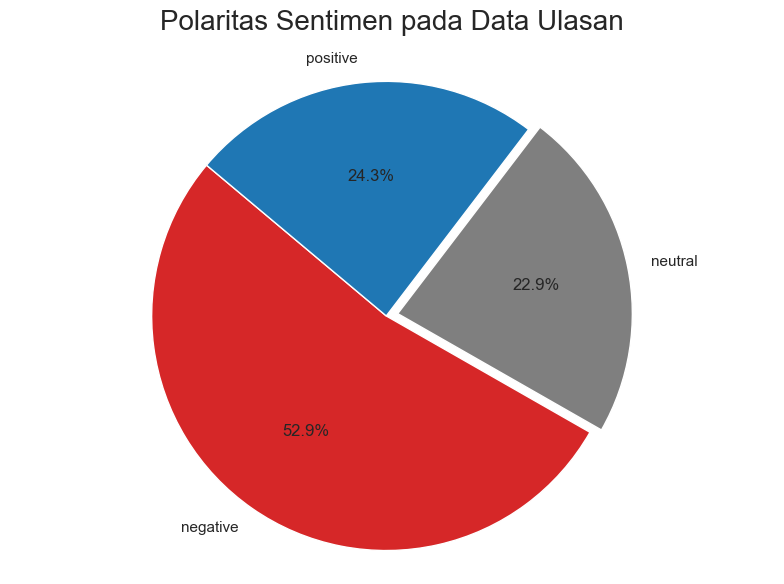

In [213]:
# Visualisasi Pie Chart Kategori Polaritas
polarity_counts = labelled_df['polarity'].value_counts()

# Mengurutkan berdasarkan label agar explode-nya tepat (opsional)
labels = ['negative', 'neutral', 'positive']
counts = [polarity_counts.get(label, 0) for label in labels]

explode = [0, 0.05, 0]  
colors = ['#d62728', '#7f7f7f', '#1f77b4']

# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    explode=explode, 
    startangle=140,
    colors=colors,
    labeldistance=1.1
)
plt.title('Polaritas Sentimen pada Data Ulasan', pad=20, fontsize=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()


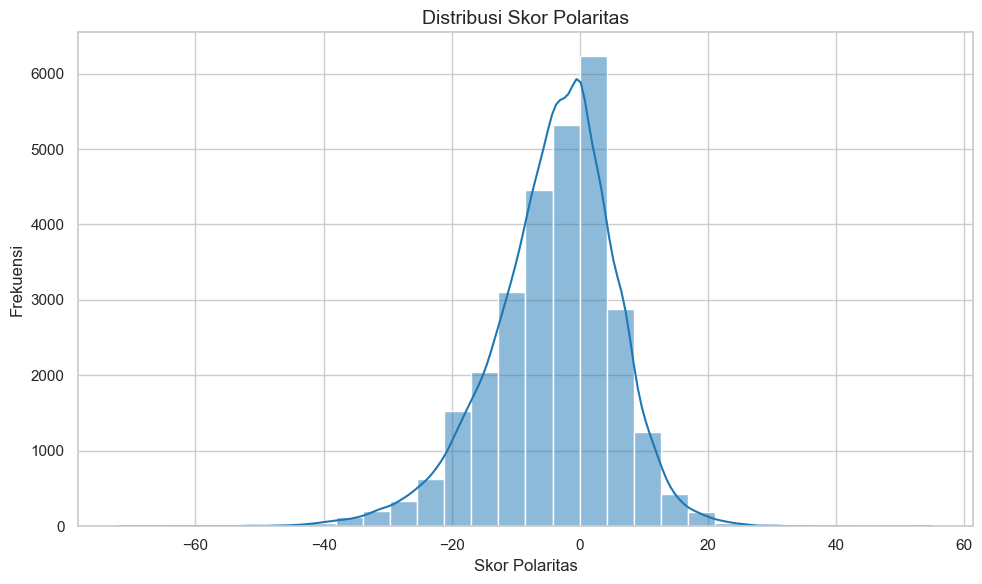

In [214]:
# Visualisasi Histogram Distribusi Skor Polaritas
sns.set(style='whitegrid')

# Histogram distribusi skor polaritas
plt.figure(figsize=(10, 6))
sns.histplot(labelled_df['polarity_score'], bins=30, kde=True, color='#1f77b4')

plt.title('Distribusi Skor Polaritas', fontsize=14)
plt.xlabel('Skor Polaritas', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.tight_layout()
plt.show()


Insight singkat berdasarkan pie chart dan histogram:
- Sebagian besar ulasan memiliki sentimen negatif yang kuat, disusul oleh sentimen positif, dan netral sebagai yang paling sedikit.
- Distribusi skor polaritas membentuk pola menyerupai distribusi normal, dengan puncak di sekitar nol, menunjukkan banyak ulasan berada di rentang netral atau tidak terlalu ekstrem.

In [215]:
labelled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28862 entries, 0 to 32999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   userName              28862 non-null  object
 1   content               28862 non-null  object
 2   score                 28862 non-null  int64 
 3   at                    28862 non-null  object
 4   text_clean            28862 non-null  object
 5   text_casefold         28862 non-null  object
 6   text_slangfix         28862 non-null  object
 7   text_tokenized        28862 non-null  object
 8   text_filtered         28862 non-null  object
 9   text_final            28862 non-null  object
 10  text_stemmed          28862 non-null  object
 11  text_string           28862 non-null  object
 12  text_casefoldingText  28862 non-null  object
 13  text_slangwords       28862 non-null  object
 14  text_tokenizingText   28862 non-null  object
 15  text_stopword         28862 non-null  obj

**Menyimpan DataFrame hasil preprocessing dan pelabelan ke dalam file CSV**

In [216]:
labelled_df.to_csv('Dataset/preprocessed_sentiment_dataset.csv', index=False)
print("Data berhasil disimpan ke 'Dataset/preprocessed_sentiment_dataset.csv'")


Data berhasil disimpan ke 'Dataset/preprocessed_sentiment_dataset.csv'


In [224]:
brimo_sentiment_df = pd.read_csv('Dataset/preprocessed_sentiment_dataset.csv')
brimo_sentiment_df[['text_string']].head()

,text_string
0,hasil update utama tampil fungsi sajasekarang ...
1,aplikasi sulit screenshot batas beda livin kak...
2,aplikasi update crash force closed teruspdahal...
3,aplikasi jelek data internet nomor daftar data...
4,update muncul notifikasi jaring buruk jaring s...


**Eksplorasi Label**

**a. WordCloud Umum (Tanpa Label)**

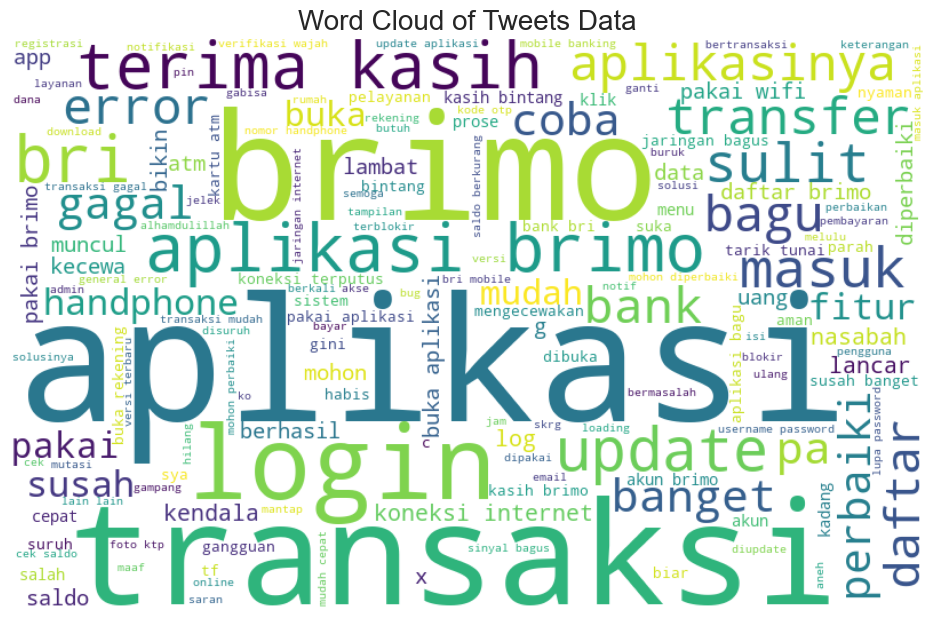

In [ ]:
# Word Cloud Umum (Tanpa Label)
all_corpus = ' '.join(
    brimo_sentiment_df['text_stopword']
    .fillna('')
    .astype(str)
    .str.replace("'", "", regex=False)  # Hapus tanda petik satu
)

wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    min_font_size=10
).generate(all_corpus)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Word Cloud of Tweets Data', fontsize=16)
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


**b. WordCloud Sentimen Negatif**

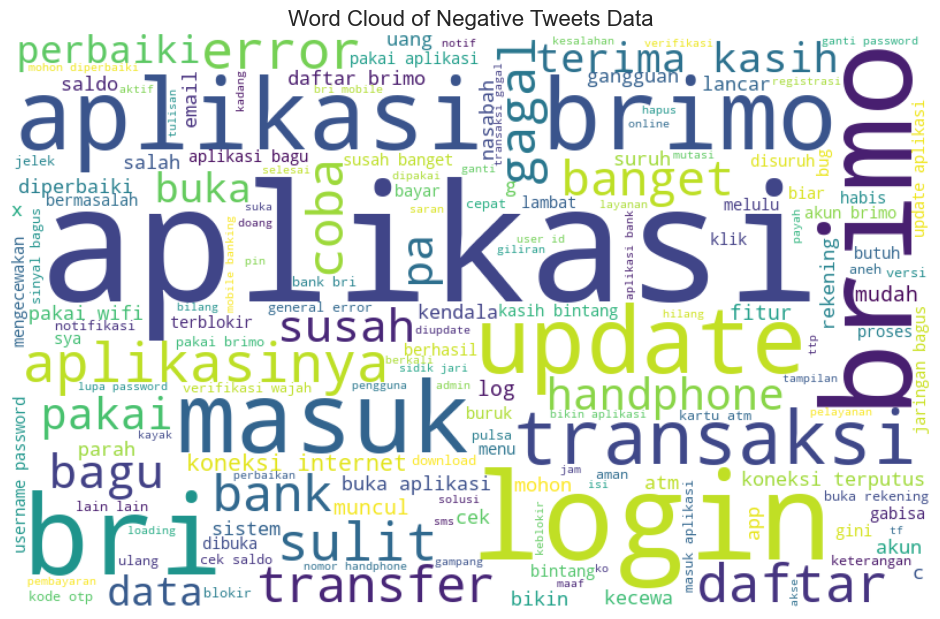

In [237]:
negative_df = brimo_sentiment_df[brimo_sentiment_df['polarity'] == 'negative']

negative_corpus = ' '.join(
    negative_df['text_stopword']
    .fillna('')
    .astype(str)
    .str.replace("'", "", regex=False)
)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    min_font_size=10
).generate(negative_corpus)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Word Cloud of Negative Tweets Data', fontsize=16)
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


**c. WordCloud Sentimen Positif**

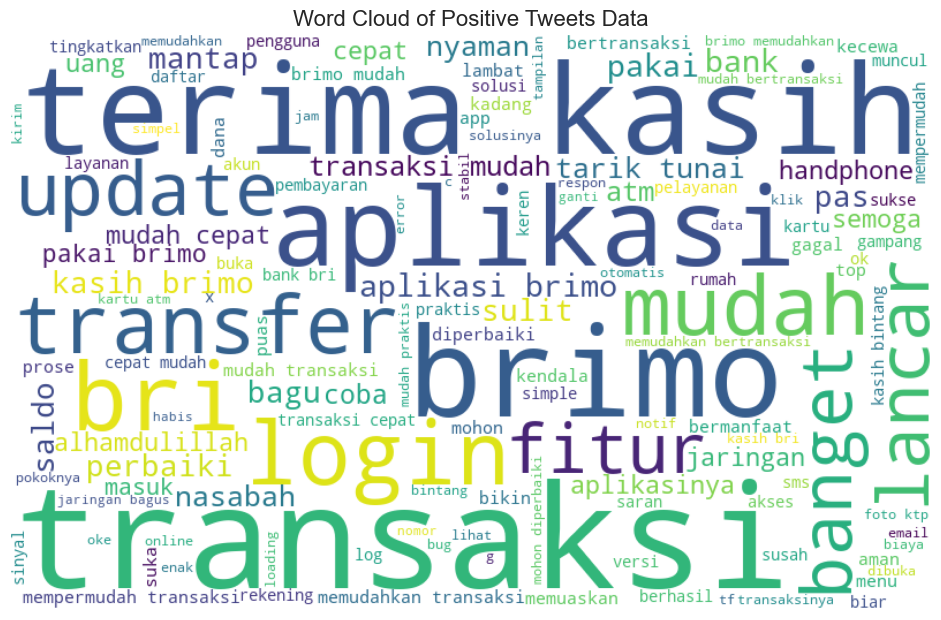

In [249]:
positive_df = brimo_sentiment_df[brimo_sentiment_df['polarity'] == 'positive']

positive_corpus = ' '.join(
    positive_df['text_stopword']
    .fillna('')
    .astype(str)
    .str.replace("'", "", regex=False)
)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    min_font_size=10
).generate(positive_corpus)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Word Cloud of Positive Tweets Data', fontsize=16)
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


**d. WordCloud Sentimen Netral**

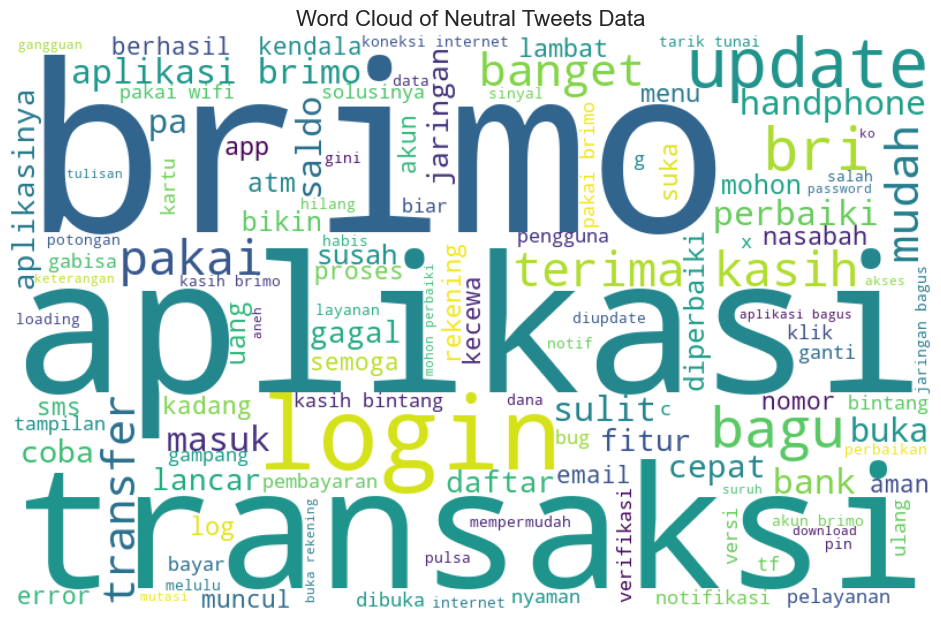

In [260]:
neutral_df = brimo_sentiment_df[brimo_sentiment_df['polarity'] == 'neutral']

neutral_corpus = ' '.join(
    neutral_df['text_stopword']
    .fillna('')
    .astype(str)
    .str.replace("'", "", regex=False)
)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    min_font_size=10
).generate(neutral_corpus)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.title('Word Cloud of Neutral Tweets Data', fontsize=16)
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


**Frekuensi Kata (TF-IDF)**

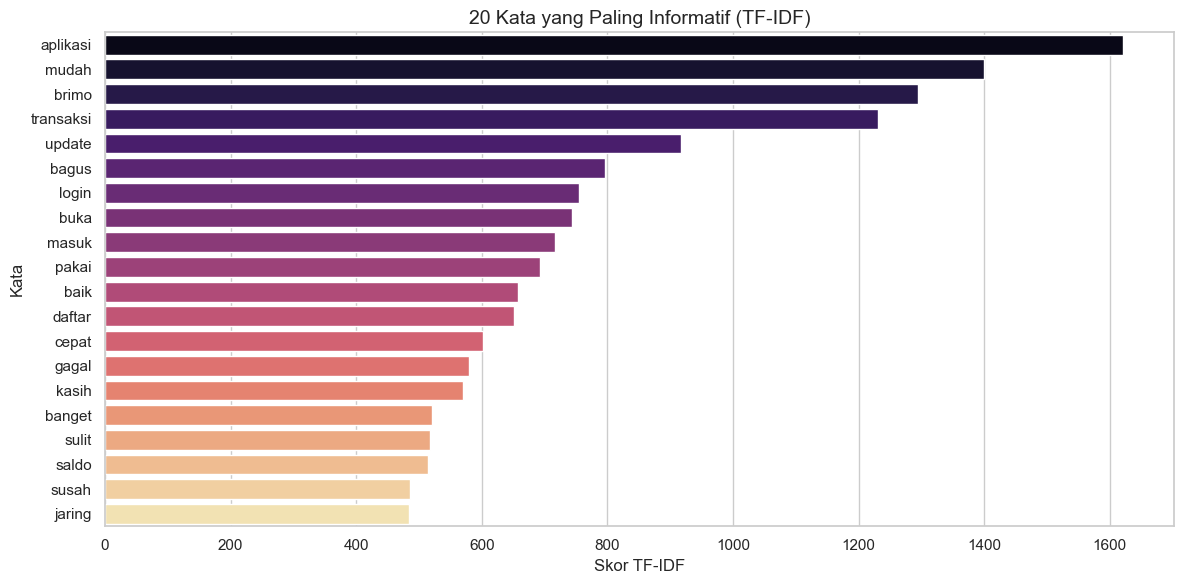

In [263]:
brimo_sentiment_df['text_string'] = brimo_sentiment_df['text_string'].fillna('').astype(str)

# Hitung TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(brimo_sentiment_df['text_string'])

# Membuat DataFrame dari hasil TF-IDF
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Jumlahkan bobot setiap kata
tfidf_sum = tfidf_df.sum().reset_index(name='jumlah')
tfidf_sum.rename(columns={'index': 'kata'}, inplace=True)

# Mengambil 20 kata teratas
tfidf_top20 = tfidf_sum.sort_values(by='jumlah', ascending=False).head(20)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(
    x='jumlah',
    y='kata',
    hue='kata',          
    data=tfidf_top20,
    palette='magma',
    legend=False         
)
plt.title('20 Kata yang Paling Informatif (TF-IDF)', fontsize=14)
plt.xlabel('Skor TF-IDF')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()


**Distribusi panjang teks**

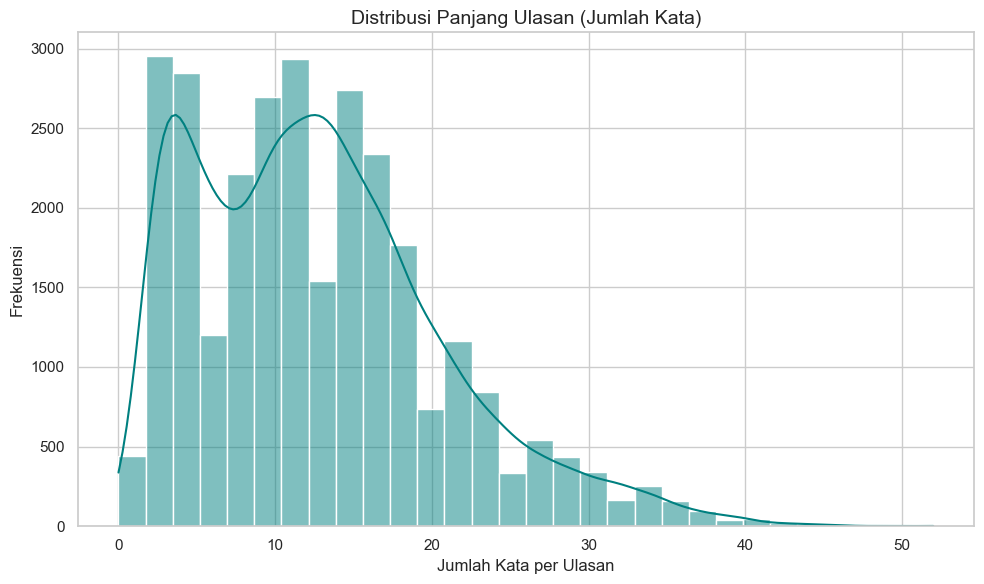

In [262]:
brimo_sentiment_df['text_string'] = brimo_sentiment_df['text_string'].fillna('').astype(str)

# Menghitung panjang teks (jumlah kata)
brimo_sentiment_df['text_length'] = brimo_sentiment_df['text_string'].apply(lambda x: len(x.split()))

# Plot distribusi panjang teks
plt.figure(figsize=(10, 6))
sns.histplot(brimo_sentiment_df['text_length'], bins=30, kde=True, color='teal')
plt.title('Distribusi Panjang Ulasan (Jumlah Kata)', fontsize=14)
plt.xlabel('Jumlah Kata per Ulasan')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()


**6. Modeling**

- Model 1: 
    - Algoritma: GRU
    - Pembagian data: Train 75%, Validation 15%, Test 10%

- Model 2: 
    - Algoritma: LSTM
    - Pembagian data: Train 70%, Validation 20%, Test 10% 

- Model 3: 
    - Algoritma: CNN
    - Pembagian data: Train 70%, Validation 15%, Test 15%

**Pra-Modeling**

Menentukan fitur teks dan label target

In [264]:
X_text = brimo_sentiment_df['text_string'].fillna('').astype(str)
y_label = brimo_sentiment_df['polarity']

# Cek beberapa baris awal untuk memastikan
print(X_text.head())
print(y_label.head())


0    hasil update utama tampil fungsi sajasekarang ...
1    aplikasi sulit screenshot batas beda livin kak...
2    aplikasi update crash force closed teruspdahal...
3    aplikasi jelek data internet nomor daftar data...
4    update muncul notifikasi jaring buruk jaring s...
Name: text_string, dtype: object
0     neutral
1    negative
2    negative
3    negative
4    positive
Name: polarity, dtype: object


Tokenisasi dan Padding

In [265]:
# Tokenisasi teks menjadi urutan angka
vocab_limit = 2500
tokenizer = Tokenizer(num_words=vocab_limit, split=' ')
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)

# Menyamakan panjang input (padding)
X_pad = pad_sequences(X_seq)

# Cek bentuk akhir fitur
print("Shape of padded input:", X_pad.shape)


Shape of padded input: (28862, 50)


Encoding Label ke One-Hot

In [266]:
# Encode label (polarity) ke bentuk numerik lalu one-hot
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_label)
y_ohe = to_categorical(y_int)

# Tampilkan informasi label
print("Shape of one-hot labels:", y_ohe.shape)
print("Total classes:", y_ohe.shape[1])


Shape of one-hot labels: (28862, 3)
Total classes: 3


**Simpan tokenizer dan label_encoder untuk inference**

In [309]:
import pickle

with open("Model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("Model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Callback Early Stopping Berdasarkan Akurasi

In [267]:
# Callback custom: hentikan training jika akurasi > 95%
class StopAtAccuracy(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        if acc is not None and acc > 0.95:
            print(f"\nAkurasi melebihi 95% pada epoch {epoch+1}, training dihentikan.")
            self.model.stop_training = True

# Inisialisasi callback
early_stop = StopAtAccuracy()


**a. Model GRU**

**1) Data splitting dan ekstrasi fitur**

Pembagian data: Train 80%, Validation 10%, Test 10%

In [288]:
# Gunakan hasil tokenisasi dan one-hot encoding sebelumnya
X_gru_input = X_pad
y_gru_label = y_ohe

# 10% untuk test, sisanya train+val
X_gru_trainval, X_gru_test, y_gru_trainval, y_gru_test = train_test_split(
    X_gru_input, y_gru_label, test_size=0.10, random_state=42)

# Dari sisanya, ambil 1/8 (~11.1%) untuk validasi (agar total val = 10%)
val_share = 1 / 8
X_gru_train, X_gru_val, y_gru_train, y_gru_val = train_test_split(
    X_gru_trainval, y_gru_trainval, test_size=val_share, random_state=42)

# Cek ukuran
print("GRU Train shape:", X_gru_train.shape)
print("GRU Validation shape:", X_gru_val.shape)
print("GRU Test shape:", X_gru_test.shape)


GRU Train shape: (22728, 50)
GRU Validation shape: (3247, 50)
GRU Test shape: (2887, 50)


**2) Membangun Model GRU**

In [289]:
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, GRU, Dense, Dropout, BatchNormalization

# Parameter
vocab_size = 2500
max_length = X_gru_input.shape[1]
num_classes = y_gru_label.shape[1]

# Arsitektur GRU yang diperbarui
gru_model = Sequential()
gru_model.add(Embedding(input_dim=vocab_size, output_dim=512, input_length=max_length))
gru_model.add(SpatialDropout1D(0.4))

gru_model.add(Bidirectional(GRU(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(0.001))))
gru_model.add(Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(0.001))))
gru_model.add(GlobalMaxPooling1D())  # Ganti GRU terakhir dengan GlobalMaxPooling

gru_model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.5))

gru_model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
gru_model.add(BatchNormalization())
gru_model.add(Dropout(0.5))

gru_model.add(Dense(num_classes, activation='softmax'))

# Kompilasi
gru_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
gru_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**3) Melatih dan Mengevaluasi Model GRU**

In [290]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks
early_stop = StopAtAccuracy()
val_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-5)

# Training
history_gru = gru_model.fit(
    X_gru_train, y_gru_train,
    epochs=50,
    batch_size=256,
    verbose=2,
    validation_data=(X_gru_val, y_gru_val),
    callbacks=[early_stop, val_stop, reduce_lr]
)

# Evaluasi
score_gru, acc_gru = gru_model.evaluate(X_gru_test, y_gru_test, verbose=2)
print("GRU Test score: %.2f" % score_gru)
print("GRU Test accuracy: %.2f" % acc_gru)

Epoch 1/50
89/89 - 83s - 938ms/step - accuracy: 0.5324 - loss: 3.1244 - val_accuracy: 0.6406 - val_loss: 2.3290 - learning_rate: 5.0000e-04
Epoch 2/50
89/89 - 78s - 876ms/step - accuracy: 0.7404 - loss: 1.8618 - val_accuracy: 0.7148 - val_loss: 1.8661 - learning_rate: 5.0000e-04
Epoch 3/50
89/89 - 77s - 865ms/step - accuracy: 0.8054 - loss: 1.5194 - val_accuracy: 0.7699 - val_loss: 1.5834 - learning_rate: 5.0000e-04
Epoch 4/50
89/89 - 79s - 889ms/step - accuracy: 0.8385 - loss: 1.3758 - val_accuracy: 0.8386 - val_loss: 1.3787 - learning_rate: 5.0000e-04
Epoch 5/50
89/89 - 82s - 920ms/step - accuracy: 0.8541 - loss: 1.2807 - val_accuracy: 0.8654 - val_loss: 1.2431 - learning_rate: 5.0000e-04
Epoch 6/50
89/89 - 81s - 909ms/step - accuracy: 0.8673 - loss: 1.1961 - val_accuracy: 0.8654 - val_loss: 1.1846 - learning_rate: 5.0000e-04
Epoch 7/50
89/89 - 79s - 891ms/step - accuracy: 0.8788 - loss: 1.1187 - val_accuracy: 0.8617 - val_loss: 1.1155 - learning_rate: 5.0000e-04
Epoch 8/50
89/89 - 7

**4) Menyimpan Model GRU** (belum disave)

In [291]:
gru_model.save("Model/gru_model_brimo.h5")


**b. Model LSTM**

Pembagian data: Train 70%, Validation 20%, Test 10% 

**1) Data splitting dan ekstrasi fitur**

In [274]:
# Gunakan data hasil tokenisasi & one-hot encoding sebelumnya
X_lstm_input = X_pad
y_lstm_label = y_ohe

# 10% untuk test, 90% sisanya untuk train+val
X_lstm_trainval, X_lstm_test, y_lstm_trainval, y_lstm_test = train_test_split(
    X_lstm_input, y_lstm_label, test_size=0.10, random_state=42)

# 2/9 dari sisa digunakan untuk val agar val 20% total (70:20:10)
X_lstm_train, X_lstm_val, y_lstm_train, y_lstm_val = train_test_split(
    X_lstm_trainval, y_lstm_trainval, test_size=2/9, random_state=42)

print("LSTM Train shape:", X_lstm_train.shape)
print("LSTM Validation shape:", X_lstm_val.shape)
print("LSTM Test shape:", X_lstm_test.shape)


LSTM Train shape: (20202, 50)
LSTM Validation shape: (5773, 50)
LSTM Test shape: (2887, 50)


**2) Membangun Model LSTM**

In [277]:
# Parameter
vocab_size = 2500
max_length = X_lstm_input.shape[1]
num_classes = y_lstm_label.shape[1]

# Arsitektur
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_length))
lstm_model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01), return_sequences=True))
lstm_model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(num_classes, activation='softmax'))


lstm_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
lstm_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**3) Melatih dan Mengevaluasi Model LSTM**

In [278]:
# Training
history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=50,
    batch_size=2056,
    verbose=2,
    validation_data=(X_lstm_val, y_lstm_val),
    callbacks=[early_stop]
)

# Evaluasi
score_lstm, acc_lstm = lstm_model.evaluate(X_lstm_test, y_lstm_test, verbose=2)
print("LSTM Test score: %.2f" % score_lstm)
print("LSTM Test accuracy: %.2f" % acc_lstm)


Epoch 1/50
10/10 - 15s - 1s/step - accuracy: 0.5060 - loss: 5.4997 - val_accuracy: 0.5273 - val_loss: 4.6657
Epoch 2/50
10/10 - 10s - 1s/step - accuracy: 0.5882 - loss: 4.1359 - val_accuracy: 0.6144 - val_loss: 3.5168
Epoch 3/50
10/10 - 10s - 1s/step - accuracy: 0.6457 - loss: 3.0983 - val_accuracy: 0.7071 - val_loss: 2.6006
Epoch 4/50
10/10 - 10s - 988ms/step - accuracy: 0.7226 - loss: 2.2792 - val_accuracy: 0.7405 - val_loss: 1.9293
Epoch 5/50
10/10 - 10s - 976ms/step - accuracy: 0.7683 - loss: 1.6982 - val_accuracy: 0.7894 - val_loss: 1.4562
Epoch 6/50
10/10 - 10s - 1s/step - accuracy: 0.8055 - loss: 1.2831 - val_accuracy: 0.8153 - val_loss: 1.1191
Epoch 7/50
10/10 - 10s - 1s/step - accuracy: 0.8333 - loss: 0.9865 - val_accuracy: 0.8344 - val_loss: 0.8832
Epoch 8/50
10/10 - 10s - 1s/step - accuracy: 0.8522 - loss: 0.7806 - val_accuracy: 0.8562 - val_loss: 0.7147
Epoch 9/50
10/10 - 12s - 1s/step - accuracy: 0.8760 - loss: 0.6250 - val_accuracy: 0.8699 - val_loss: 0.5971
Epoch 10/50
1

**4) Menyimpan Model LSTM** 

In [292]:
lstm_model.save("Model/lstm_model.h5")

**c. Model CNN**

Pembagian data: Train 70%, Validation 15%, Test 15%

**1) Data splitting dan ekstrasi fitur**

In [282]:
X_cnn_input = X_pad  # hasil pad_sequences sebelumnya
y_cnn_label = y_ohe  # hasil one-hot encoding label

X_cnn_trainval, X_cnn_test, y_cnn_trainval, y_cnn_test = train_test_split(X_cnn_input, y_cnn_label, test_size=0.15, random_state=42)
val_ratio = 15 / 70
X_cnn_train, X_cnn_val, y_cnn_train, y_cnn_val = train_test_split(X_cnn_trainval, y_cnn_trainval, test_size=val_ratio, random_state=42)

print("CNN Train shape:", X_cnn_train.shape)
print("CNN Validation shape:", X_cnn_val.shape)
print("CNN Test shape:", X_cnn_test.shape)


CNN Train shape: (19275, 50)
CNN Validation shape: (5257, 50)
CNN Test shape: (4330, 50)


**2) Membangun Model CNN**

In [283]:
# Parameter
vocab_size = 2500
max_length = X_cnn_input.shape[1]
num_classes = y_cnn_label.shape[1]

# Arsitektur
cnn_model = Sequential()
cnn_model.add(Embedding(input_dim=vocab_size, output_dim=512, input_length=max_length))
cnn_model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
# Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(num_classes, activation='softmax'))

# Kompilasi
cnn_model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
cnn_model.summary()


c:\Users\chata\anaconda3\envs\main-ds\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**3) Melatih dan Mengevaluasi Model CNN**

In [284]:
# Melatih dan Mengevaluasi Model CNN
from tensorflow.keras.callbacks import EarlyStopping

val_stop = EarlyStopping(monitor='val_accuracy', patience=5, 
                           restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_cnn_train, y_cnn_train,
    epochs=50,
    batch_size=1028,
    verbose=2,
    validation_data=(X_cnn_val, y_cnn_val),
    callbacks=[early_stop, val_stop]
)

score_cnn, acc_cnn = cnn_model.evaluate(X_cnn_test, y_cnn_test, verbose=2, batch_size=1028)
print("CNN Test score: %.2f" % score_cnn)
print("CNN Test accuracy: %.2f" % acc_cnn)


Epoch 1/50
19/19 - 5s - 282ms/step - accuracy: 0.5164 - loss: 0.9804 - val_accuracy: 0.6313 - val_loss: 0.8151
Epoch 2/50
19/19 - 3s - 161ms/step - accuracy: 0.6472 - loss: 0.7471 - val_accuracy: 0.6481 - val_loss: 0.7076
Epoch 3/50
19/19 - 3s - 166ms/step - accuracy: 0.7495 - loss: 0.5873 - val_accuracy: 0.8229 - val_loss: 0.4831
Epoch 4/50
19/19 - 3s - 153ms/step - accuracy: 0.8339 - loss: 0.4143 - val_accuracy: 0.8587 - val_loss: 0.3724
Epoch 5/50
19/19 - 3s - 162ms/step - accuracy: 0.8803 - loss: 0.3151 - val_accuracy: 0.8657 - val_loss: 0.3535
Epoch 6/50
19/19 - 3s - 157ms/step - accuracy: 0.9084 - loss: 0.2582 - val_accuracy: 0.8779 - val_loss: 0.3650
Epoch 7/50
19/19 - 3s - 149ms/step - accuracy: 0.9244 - loss: 0.2224 - val_accuracy: 0.8743 - val_loss: 0.3811
Epoch 8/50
19/19 - 3s - 152ms/step - accuracy: 0.9372 - loss: 0.1893 - val_accuracy: 0.8699 - val_loss: 0.4016
Epoch 9/50

Akurasi melebihi 95% pada epoch 9, training dihentikan.
19/19 - 3s - 153ms/step - accuracy: 0.9508 -

**4) Menyimpan Model CNN** 

In [293]:
cnn_model.save("Model/cnn_model.h5")

**Evaluasi Ketiga Model**

In [329]:
# Buat DataFrame hasil akurasi
evaluation_df = pd.DataFrame({
    'Model': ['GRU', 'LSTM', 'CNN'],
    'Train Accuracy': [
        history_gru.history['accuracy'][-1],
        history_lstm.history['accuracy'][-1],
        history_cnn.history['accuracy'][-1]
    ],
    'Test Accuracy': [acc_gru, acc_lstm, acc_cnn]
})

print(evaluation_df)


  Model  Train Accuracy  Test Accuracy
0   GRU        0.923926       0.890197
1  LSTM        0.950549       0.887426
2   CNN        0.950817       0.876443


**Visualisasi Perbandingan Akurasi untuk Ketiga Model**

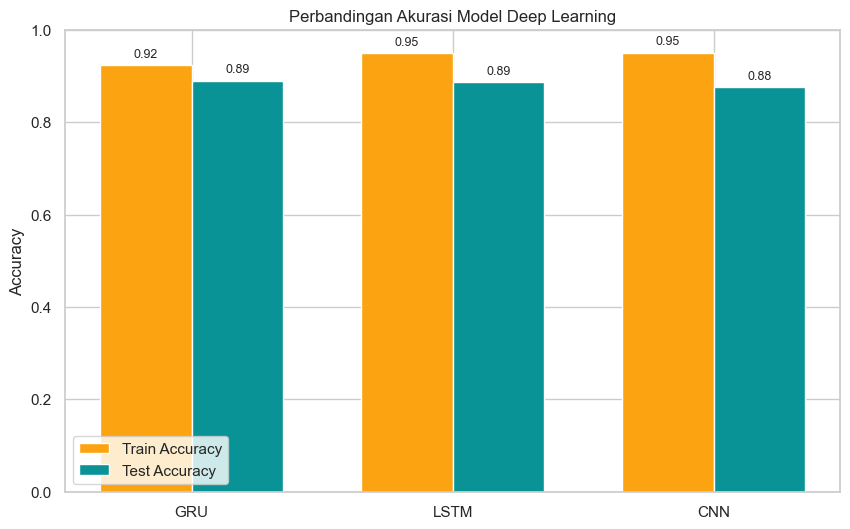

In [328]:
# Style plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Data
model_names = evaluation_df['Model']
train_accuracies = evaluation_df['Train Accuracy']
test_accuracies = evaluation_df['Test Accuracy']

x_pos = range(len(model_names))
bar_width = 0.35

# Plot bar
bars_train = plt.bar([x - bar_width/2 for x in x_pos], train_accuracies, width=bar_width, label='Train Accuracy', color='#fca311')
bars_test  = plt.bar([x + bar_width/2 for x in x_pos], test_accuracies, width=bar_width, label='Test Accuracy', color='#0a9396')

# Label 
for bar in bars_train:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars_test:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)


plt.xticks(x_pos, model_names)
plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi Model Deep Learning')
plt.ylim(0, 1)
plt.legend()
plt.show()
